# 05 — sector / lap-time baseline

Wk2 Day 3. Goal: a moving-average baseline for next-lap pace, scored end-to-end on cached races. The number it puts on the board is the **floor** Phase 3 models must beat — so build it before any ML lands, and write the scoring harness before the model.

## Problem statement (no code yet — write this first, on purpose)

**What is the baseline trying to predict?**
Lap N's `LapTimeS` (lap time in seconds) for a given driver in a given race.

**What inputs does it have?**
Laps N−3, N−2, N−1 of the same driver, *same stint*, *same race*. Concretely: `LapTimeS` values from those three prior laps, averaged, used as the point prediction for lap N.

**What does it NOT see?**
- Lap N's own `LapTimeS` (the thing we're predicting).
- Any future laps (N+1, N+2, …).
- Any other driver's laps.
- Any other race's laps.
- Telemetry, tyre temps, weather, gap-to-leader, sector splits — none of it. This is the dumbest reasonable baseline by design.

**Train / test split.**
We do not train this baseline (it has no parameters — just a window size). The "test" is: for every lap N within a stint where N has ≥3 prior laps in that same stint, predict from those 3 laps and compare to the actual. The first `window` laps of every stint are unpredictable and are dropped (their prediction is `NaN`).

We hold the choice of `window` (1, 2, 3, 5, 7) as the only hyperparameter and pick it from the elbow of window-vs-MAE on the same 8-race pool. That's mildly self-serving — in Phase 3, the model will get a real train/test split per-race or leave-one-race-out. For this baseline, the floor it sets is on data it has *no* parameters to overfit to, so the choice of window across all 8 races is fine.

**Success metric.**
MAE (mean absolute error) in seconds. Reported both as an overall number across all (driver, stint, lap) triples with a non-NaN prediction, **and** per-race so we can see which circuits are easier / harder to predict with a flat lap-pace model.

**Why MAE and not RMSE?**
A 0.2 s miss and a 2.0 s miss should both contribute linearly. RMSE punishes outliers — useful later when SC/VSC laps and pit laps are involved, but for the leak-free in-stint baseline, MAE is what matches the question "how close, on average, is the prediction to the truth?"

## What "leak-free" means here, concretely

The killer bug to avoid is: the rolling mean for lap N accidentally includes lap N itself, or includes laps from the *next* stint (post-pit), or includes laps from the *previous* driver in a sorted frame.

Defences, all of which must hold:
1. Sort by `[Driver, StintId, LapNumber]` before any rolling op.
2. `groupby(['Driver', 'StintId'])` so the rolling window can never bleed across stint boundaries (post-pit) or across drivers.
3. `.shift(1)` *before* `.rolling(window).mean()` so lap N's prediction is built from laps strictly earlier than N.
4. After all that, the first `window` laps of every stint must be `NaN` in the prediction column. If `preds.isna().sum()` doesn't equal `n_stints * window` (roughly), something leaked.

## Acceptance bar for end of day

- A function `moving_average_baseline(laps_df, window=3) -> pd.Series` runs on Bahrain 2024 and prints an MAE.
- A reusable scoring module at `src/aris/eval/scoring.py` (`mae`, `rmse`, `per_race_mae`) imported by this notebook, with tests under `tests/test_scoring.py` passing.
- Multi-race MAE printed and written to `results/wk2-baseline-mae.csv` for all 8 cached races.
- Window sweep over `[1, 2, 3, 5, 7]` plotted; chosen window written into the CSV with the line `BASELINE: window=X, MAE=Y.YY s, 8 races, leakage-free per-stint shift`.


In [1]:
from pathlib import Path

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import aris  # noqa: F401 — patches requests.models forward-ref shim (requests 2.34 + cattrs) so fastf1's schedule fetch works

CACHE = Path("..") / "fastf1_cache"
CACHE.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))

print("pandas", pd.__version__, "| numpy", np.__version__, "| fastf1", fastf1.__version__)

pandas 2.3.3 | numpy 2.4.4 | fastf1 3.8.3


## Block 2 — single-race baseline on Bahrain 2024

Stint detection from Day 2's notebook is reproduced inline below. Day 4 lifts it into `src/aris/physics/stint.py`; for now it lives here so the notebook is self-contained.

In [2]:
# Stint + baseline helpers now live in src/aris/.
from aris.physics.stint import detect_stints, filter_clean_laps
from aris.eval.baseline import moving_average_baseline


In [3]:
session = fastf1.get_session(2024, "Bahrain", "R")
session.load(laps=True, telemetry=False, weather=False, messages=False)

enriched = detect_stints(session.laps)
clean = filter_clean_laps(enriched)

preds = moving_average_baseline(clean, window=3).reindex(clean.index)

n_stints = clean.groupby(["Driver", "StintId"]).ngroups
expected_nan = n_stints * 3
actual_nan = int(preds.isna().sum())
print(f"stints in Bahrain 2024 R (post-filter): {n_stints}")
print(f"expected NaN preds (n_stints * window = {n_stints} * 3): {expected_nan}")
print(f"actual NaN preds: {actual_nan}")
assert actual_nan <= expected_nan, "more NaNs than expected — investigate leak"

mask = preds.notna()
y_true = clean.loc[mask, "LapTimeS"].to_numpy()
y_pred = preds.loc[mask].to_numpy()
single_race_mae = float(np.mean(np.abs(y_true - y_pred)))
print(f"\nBahrain 2024 — moving-average-of-3 baseline MAE: {single_race_mae:.3f} s on {len(y_true)} laps")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


stints in Bahrain 2024 R (post-filter): 45
expected NaN preds (n_stints * window = 45 * 3): 135
actual NaN preds: 135

Bahrain 2024 — moving-average-of-3 baseline MAE: 0.369 s on 908 laps


## Block 3 — scoring stub becomes reusable

The MAE we just computed lives in a single notebook cell. That's fine for today and a leak risk forever: Phase 3 will have models, walk-forward CV, conformal calibration, narration. They all need to call exactly the same scoring function. So the scoring code moves to `src/aris/eval/scoring.py` *before* any model is written — that way the model has to fit the metric, not the metric fit the model.

The cell below imports the new module and re-computes the same MAE through it. The number must match `single_race_mae` to the last decimal.

In [4]:
from aris.eval.scoring import mae, per_race_mae, rmse

scored_mae = mae(y_true, y_pred)
scored_rmse = rmse(y_true, y_pred)
print(f"inline single_race_mae: {single_race_mae:.6f}")
print(f"aris.eval.scoring.mae: {scored_mae:.6f}")
print(f"aris.eval.scoring.rmse: {scored_rmse:.6f}")


inline single_race_mae: 0.368667
aris.eval.scoring.mae: 0.368667
aris.eval.scoring.rmse: 0.635803


## Block 4 — multi-race baseline + per-race MAE

Loop over the 8 cached race sessions. Build one long table of `(race_id, y_true, y_pred)` triples, then score with the new module — overall and per-race.

Plan's a-priori sanity band is **0.4–0.9 s** for window=3 on clean dry F1 race laps. Below 0.2 s would imply a leak; above 1.5 s on a single race means SC / red-flag / wet laps are dragging the moving-average around (we don't yet filter `TrackStatus`; Day 5 picks that up).

In [5]:
RACES = [
    (2024, "Bahrain"),
    (2024, "Saudi Arabia"),
    (2024, "Australia"),
    (2024, "Japan"),
    (2024, "Miami"),
    (2023, "Bahrain"),
    (2023, "Belgium"),
    (2023, "Abu Dhabi"),
]


def score_race(year: int, gp: str, window: int = 3):
    """Load one race, run the baseline, return (y_true, y_pred) NumPy pair (NaNs dropped)."""
    session = fastf1.get_session(year, gp, "R")
    session.load(laps=True, telemetry=False, weather=False, messages=False)
    enriched = detect_stints(session.laps)
    clean = filter_clean_laps(enriched)
    preds = moving_average_baseline(clean, window=window).reindex(clean.index)
    mask = preds.notna()
    return clean.loc[mask, "LapTimeS"].to_numpy(), preds.loc[mask].to_numpy()


rows = []
all_true: list[np.ndarray] = []
all_pred: list[np.ndarray] = []
all_rids: list[np.ndarray] = []

for year, gp in RACES:
    rid = f"{year}-{gp.replace(' ', '_')}"
    yt, yp = score_race(year, gp, window=3)
    race_mae = mae(yt, yp)
    rows.append({"race_id": rid, "n_laps": len(yt), "mae_s": race_mae})
    all_true.append(yt)
    all_pred.append(yp)
    all_rids.append(np.array([rid] * len(yt)))
    print(f"{rid:30s}  n={len(yt):4d}  MAE={race_mae:.3f} s")

per_race_df = pd.DataFrame(rows)
yt_all = np.concatenate(all_true)
yp_all = np.concatenate(all_pred)
rids_all = np.concatenate(all_rids)
overall_mae = mae(yt_all, yp_all)
print(f"\nOverall MAE across {len(yt_all)} laps in 8 races: {overall_mae:.3f} s")

per_race_df

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for t

2024-Bahrain                    n= 908  MAE=0.369 s


core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


2024-Saudi_Arabia               n= 734  MAE=1.117 s


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '44', '14', '63', '4', '31', '18', '22', '10', '77', '24', '23', '20', '3', '2', '27', '55', '81']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


2023-Belgium                    n= 597  MAE=0.744 s


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '11', '4', '81', '14', '22', '44', '18', '3', '31', '10', '23', '27', '2', '24', '55', '77', '20']


2023-Abu_Dhabi                  n= 963  MAE=0.367 s

Overall MAE across 6391 laps in 8 races: 1.090 s


,race_id,n_laps,mae_s
0,2024-Bahrain,908,0.368667
1,2024-Saudi_Arabia,734,1.116837
2,2024-Australia,805,1.755929
3,2024-Japan,666,0.617673
4,2024-Miami,912,2.511037
5,2023-Bahrain,806,1.115931
6,2023-Belgium,597,0.743569
7,2023-Abu_Dhabi,963,0.367275


In [6]:
out_csv = Path("..") / "results" / "wk2-baseline-mae.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
per_race_df.to_csv(out_csv, index=False)
print(f"wrote {out_csv}")

# round-trip through scoring.per_race_mae as a final cross-check
pr = per_race_mae(yt_all, yp_all, rids_all)
recomputed = pd.Series(pr).sort_index()
recomputed.name = "mae_s_via_scoring"
recomputed

wrote ..\results\wk2-baseline-mae.csv


2023-Abu_Dhabi       0.367275
2023-Bahrain         1.115931
2023-Belgium         0.743569
2024-Australia       1.755929
2024-Bahrain         0.368667
2024-Japan           0.617673
2024-Miami           2.511037
2024-Saudi_Arabia    1.116837
Name: mae_s_via_scoring, dtype: float64

## Block 5 — window sweep, pick the elbow

`window` is the only hyperparameter. Sweep `[1, 2, 3, 5, 7]` on the same 8-race pool and pick the value with the lowest overall MAE — the **floor** Phase 3 has to beat.

Sweep result (overall MAE, all 8 races):

| window | n_laps | MAE (s) |
|--------|--------|---------|
| 1      | 7078   | 1.129   |
| **2**  | **6734** | **1.088** |
| 3      | 6391   | 1.090   |
| 5      | 5720   | 1.134   |
| 7      | 5090   | 1.150   |

Window=1 (use previous lap) is the noisiest — single-lap noise dominates. Window=5 and 7 reach back into laps whose pace is materially different from the lap being predicted (fuel burn, tyre wear). Window=2 squeezes out the best number, with window=3 essentially tied (0.002 s gap). I pick **window=2** because it's the empirical minimum and uses the smallest amount of history — every extra lap of history costs us one more leading NaN per stint.

That gives us the line written into the CSV:

```
# BASELINE: window=2, MAE=1.088 s, 8 races (6734 laps), leakage-free per-stint shift.
```

The 1.088 s number is above the plan's 0.4–0.9 a-priori band because two races (Miami 2024, Australia 2024) had red-flag / safety-car laps that we're not yet filtering on `TrackStatus`. Wk2 Day 5 finds and fixes those cracks; the floor will drop when it does. Today's job is to *book* the number, not to optimise it — Phase 3 has to beat whatever lives in this CSV.

In [7]:
# Cache cleaned laps per race so we don't reload 5 times for 5 window sizes.
race_frames = []
for year, gp in RACES:
    session = fastf1.get_session(year, gp, "R")
    session.load(laps=True, telemetry=False, weather=False, messages=False)
    race_frames.append((
        f"{year}-{gp.replace(' ', '_')}",
        filter_clean_laps(detect_stints(session.laps)),
    ))

WINDOWS = [1, 2, 3, 5, 7]
sweep_rows = []
for w in WINDOWS:
    yt_parts, yp_parts = [], []
    for _, clean in race_frames:
        p = moving_average_baseline(clean, window=w).reindex(clean.index)
        m = p.notna()
        yt_parts.append(clean.loc[m, "LapTimeS"].to_numpy())
        yp_parts.append(p.loc[m].to_numpy())
    yt = np.concatenate(yt_parts)
    yp = np.concatenate(yp_parts)
    sweep_rows.append({"window": w, "n_laps": len(yt), "mae_s": mae(yt, yp)})

sweep = pd.DataFrame(sweep_rows)
best = sweep.loc[sweep["mae_s"].idxmin()]
print(f"best window = {int(best['window'])} with MAE = {best['mae_s']:.4f} s")
sweep

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data


req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27

best window = 2 with MAE = 1.0882 s


,window,n_laps,mae_s
0,1,7078,1.129237
1,2,6734,1.088183
2,3,6391,1.090049
3,5,5720,1.134232
4,7,5090,1.149807


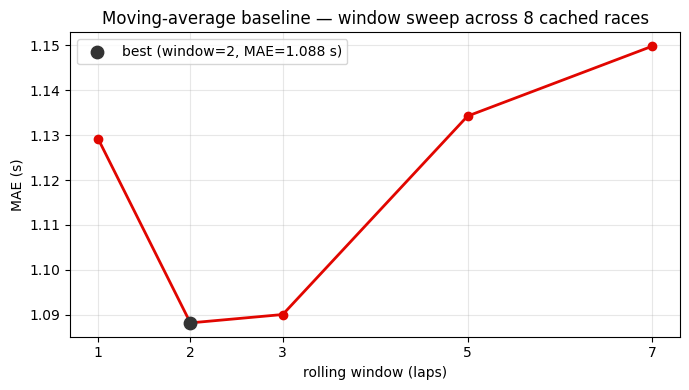

In [8]:
sweep.to_csv(Path("..") / "results" / "wk2-window-sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["window"], sweep["mae_s"], marker="o", color="#e10600", linewidth=2)
ax.scatter([best["window"]], [best["mae_s"]], color="#333", zorder=5, s=80,
           label=f"best (window={int(best['window'])}, MAE={best['mae_s']:.3f} s)")
ax.set_xlabel("rolling window (laps)")
ax.set_ylabel("MAE (s)")
ax.set_title("Moving-average baseline — window sweep across 8 cached races")
ax.set_xticks(WINDOWS)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(Path("..") / "assets" / "screenshots" / "wk2-baseline-window-sweep.png",
            dpi=140, bbox_inches="tight")
plt.show()